In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', columns=['SV1_DESI_TARGET', 'TARGETS', 'coadd_type']))
mask = (tmp['SV1_DESI_TARGET'] & 2**0 > 0) & (tmp['TARGETS']=='QSO+LRG') & (tmp['coadd_type']=='cumulative')
idx = np.where(mask)[0]
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

52268
52023


In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05


In [6]:
# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

Min depth 31466 11902 0.7255580151263604
31466


In [7]:
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

31466
31408


In [8]:
# Remove duplicates
_, idx = np.unique(zbest['TARGETID'], return_index=True)
zbest = zbest[idx]
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

31408
31408


In [9]:
# Ting-Wen's quality cuts
mask = zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['Z']<1.4
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['DELTACHI2']>15
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 31154 254 0.9919128884360673
Quality cuts 30802 606 0.9807055527254203
Quality cuts 30678 730 0.9767575140091697
30678


__Add MEDIUM and WISE masks and require NOBS>=2__

In [10]:
maskbits = [1, 8, 11, 12, 13]
min_nobs = 2

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

# mask_clean &= (zbest['NOBS_G']>=min_nobs) & (zbest['NOBS_R']>=min_nobs) & (zbest['NOBS_Z']>=min_nobs)
# print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]

0.07940543712106396


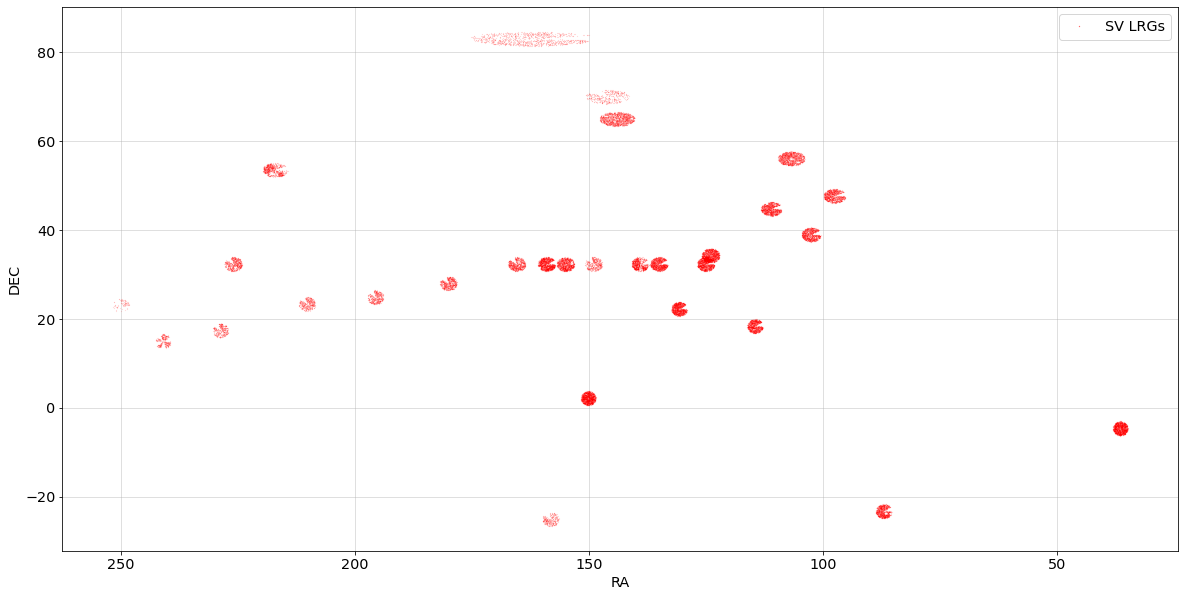

In [11]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [12]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']) - 3.214 * zbest['EBV']
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']) - 2.165 * zbest['EBV']
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']) - 1.211 * zbest['EBV']
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']) - 0.184 * zbest['EBV']
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']) - 0.113 * zbest['EBV']
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']) - 3.214 * zbest['EBV']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']) - 2.165 * zbest['EBV']
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']) - 1.211 * zbest['EBV']

In [13]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [14]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# mask_north = zbest['PHOTSYS']=='N'
# mask_south = zbest['PHOTSYS']=='S'

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

10508


--------
# Get photo-z's

In [15]:
from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

# ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'NOBS_G', 'NOBS_R', 'NOBS_Z']

# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(zbest, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for index, sweep_fn in enumerate(sweep_fn_list):
    print(index, len(sweep_fn_list))
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, zbest['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    # if '/south/sweep/' in sweep_fn:
    #     ls['field'] = 'south'
    # else:
    #     ls['field'] = 'north'
    pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    pz = Table(fitsio.read(pz_fn, rows=idx))
    pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    pz['TARGETID'] = targetid
    ls_stack.append(pz)
ls = vstack(ls_stack)
print(len(zbest), len(ls))

zbest = join(zbest, ls, keys='TARGETID')

64
0 64
1 64
2 64
3 64
4 64
5 64
6 64
7 64
8 64
9 64
10 64
11 64
12 64
13 64
14 64
15 64
16 64
17 64
18 64
19 64
20 64
21 64
22 64
23 64
24 64
25 64
26 64
27 64
28 64
29 64
30 64
31 64
32 64
33 64
34 64
35 64
36 64
37 64
38 64
39 64
40 64
41 64
42 64
43 64
44 64
45 64
46 64
47 64
48 64
49 64
50 64
51 64
52 64
53 64
54 64
55 64
56 64
57 64
58 64
59 64
60 64
61 64
62 64
63 64
28242 28242


In [31]:
zbest.write('/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/denali_lrg_photo-z_added.fits', overwrite=True)

In [23]:
len(zbest)

28242

In [16]:
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)
np.sum(mask_star)/len(mask_star)

0.01448197719708236

In [17]:
sys.path.append(os.path.expanduser('~/git/desi-photoz/'))
import pz_modules

In [18]:
z_phot = zbest['Z_PHOT_MEDIAN']
z_spec = zbest['Z']

In [30]:
np.sum(lrg_sv3)/len(lrg_sv3)

0.3720699667162382

Normalized MAD: 0.031869
0.10 outliers: 5.252758%


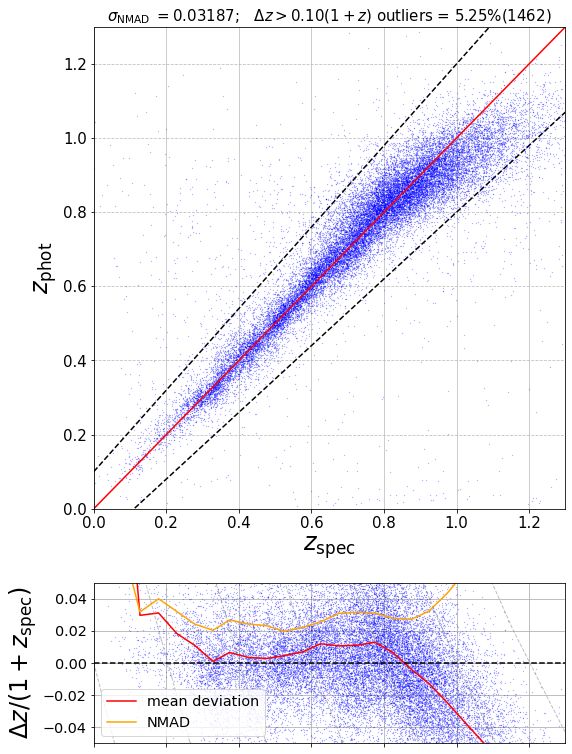

In [35]:
# SV1
mask = np.full(len(zbest), True)
mask &= (~mask_star)
pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=0.5, zmin=0.0, zmax=1.3, verbose=False, dz_range=0.05, z_binsize=0.05, outlier_threshold=0.1, alpha=0.5)

Normalized MAD: 0.028201
0.10 outliers: 3.849469%


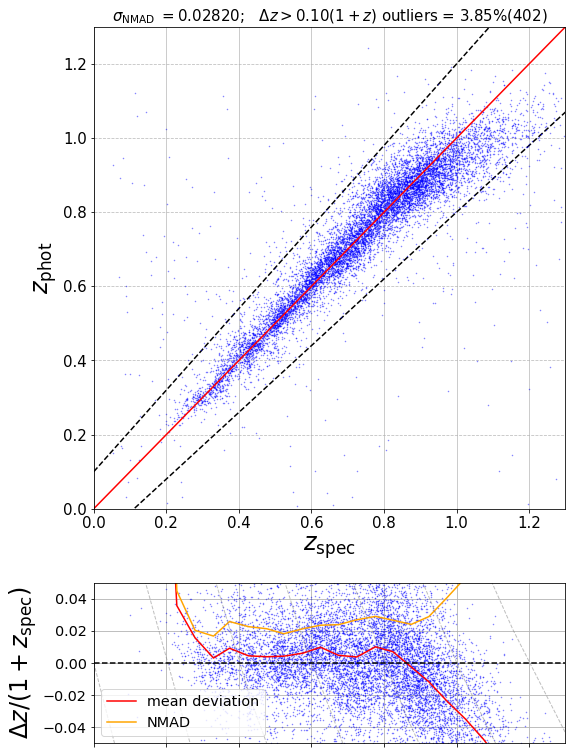

In [36]:
# SV3
mask = lrg_sv3.copy()
mask &= (~mask_star)
pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=1, zmin=0.0, zmax=1.3, verbose=False, dz_range=0.05, z_binsize=0.05, outlier_threshold=0.1, alpha=0.5)

14243
Normalized MAD: 0.029412
0.10 outliers: 4.654918%


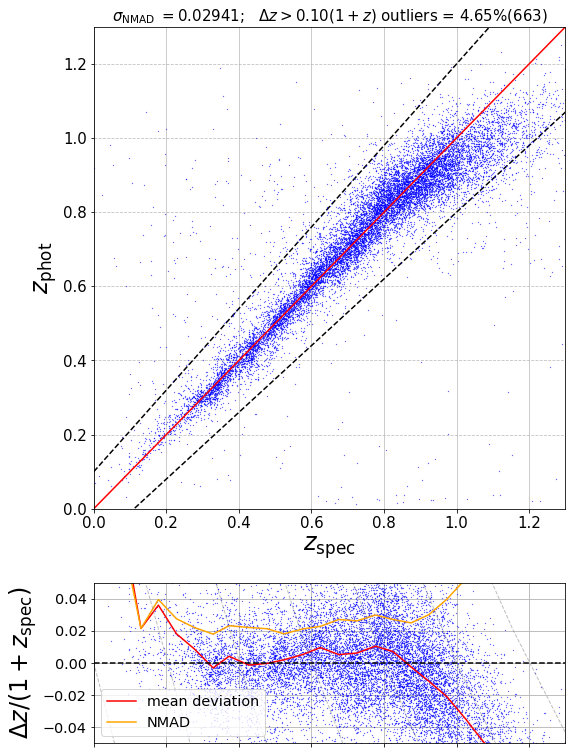

In [40]:
# SV1 south
mask = np.full(len(zbest), True)
mask &= (~mask_star)
mask &= mask_south
print(np.sum(mask))
pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=0.5, zmin=0.0, zmax=1.3, verbose=False, dz_range=0.05, z_binsize=0.05, outlier_threshold=0.1, alpha=1)

13590
Normalized MAD: 0.034672
0.10 outliers: 5.879323%


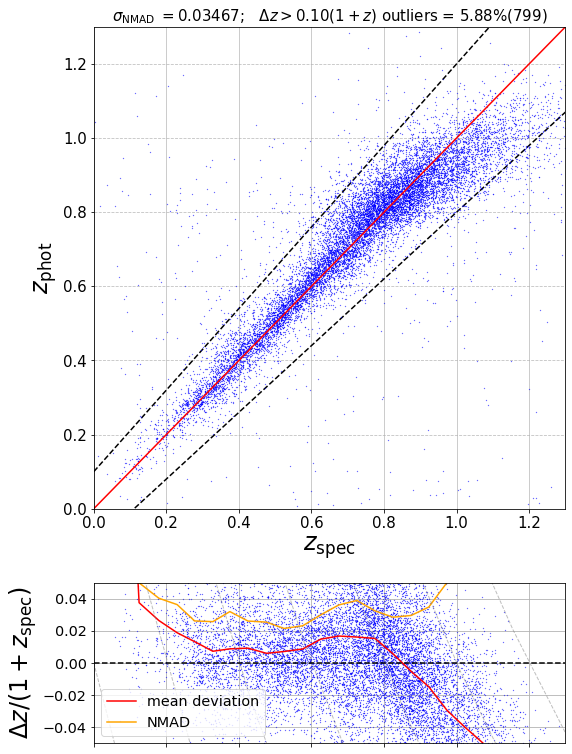

In [39]:
# SV1 north
mask = np.full(len(zbest), True)
mask &= (~mask_star)
mask &= mask_north
print(np.sum(mask))
pz_modules.plot_photoz_specz(z_phot[mask], z_spec[mask], markersize=0.5, zmin=0.0, zmax=1.3, verbose=False, dz_range=0.05, z_binsize=0.05, outlier_threshold=0.1, alpha=1)